In [ ]:
!mkdir -p /kaggle/working/SEN1-2

!rsync -av \
rsync://m1436631@dataserv.ub.tum.de/m1436631/ROIs1868_summer/ \
/kaggle/working/SEN1-2/ROIs1868_summer/

receiving incremental file list
created directory /kaggle/working/SEN1-2/ROIs1868_summer
./
s1_0/
s1_0/ROIs1868_summer_s1_0_p1.png
s1_0/ROIs1868_summer_s1_0_p10.png
s1_0/ROIs1868_summer_s1_0_p100.png
s1_0/ROIs1868_summer_s1_0_p101.png
s1_0/ROIs1868_summer_s1_0_p102.png
s1_0/ROIs1868_summer_s1_0_p103.png
s1_0/ROIs1868_summer_s1_0_p104.png
s1_0/ROIs1868_summer_s1_0_p105.png
s1_0/ROIs1868_summer_s1_0_p106.png
s1_0/ROIs1868_summer_s1_0_p107.png
s1_0/ROIs1868_summer_s1_0_p108.png
s1_0/ROIs1868_summer_s1_0_p109.png
s1_0/ROIs1868_summer_s1_0_p11.png
s1_0/ROIs1868_summer_s1_0_p110.png
s1_0/ROIs1868_summer_s1_0_p111.png
s1_0/ROIs1868_summer_s1_0_p112.png
s1_0/ROIs1868_summer_s1_0_p113.png
s1_0/ROIs1868_summer_s1_0_p114.png
s1_0/ROIs1868_summer_s1_0_p115.png
s1_0/ROIs1868_summer_s1_0_p116.png
s1_0/ROIs1868_summer_s1_0_p117.png
s1_0/ROIs1868_summer_s1_0_p118.png
s1_0/ROIs1868_summer_s1_0_p119.png
s1_0/ROIs1868_summer_s1_0_p120.png
s1_0/ROIs1868_summer_s1_0_p121.png
s1_0/ROIs1868_summer_s1_0_p122.

In [5]:
import os

root = "/kaggle/working/SEN1-2"

for path, dirs, files in os.walk(root):
    print(path)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

    if path.count(os.sep) > 3:
        break

/kaggle/working/SEN1-2
Folders: ['ROIs1868_summer']
Files: []
--------------------------------------------------
/kaggle/working/SEN1-2/ROIs1868_summer
Folders: ['s1_110', 's1_134', 's2_57', 's2_20', 's1_20']
Files: []
--------------------------------------------------


In [6]:
import os

count = 0

for root, dirs, files in os.walk("/kaggle/working/SEN1-2"):
    for file in files:
        if file.endswith((".png", ".tif", ".jpg")):
            count += 1

print("Total Images:", count)

Total Images: 107016


In [7]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm

print("PyTorch Version:", torch.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

PyTorch Version: 2.10.0+cu128
Device: cuda


In [9]:
##############################################
# Hyperparameters
##############################################

IMAGE_SIZE = 256

BATCH_SIZE = 16

NUM_EPOCHS = 50

LEARNING_RATE = 2e-4

LAMBDA_L1 = 100

NUM_WORKERS = 2

PIN_MEMORY = True

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [10]:
import os

print(os.listdir("/kaggle/input"))

[]


In [11]:
DATASET_PATH = "/kaggle/input/YOUR_FOLDER_NAME/ROIs1868_summer"

print(os.path.exists(DATASET_PATH))

False


In [12]:
import os

print(os.listdir("/kaggle/input"))

[]


In [13]:
!mkdir -p /kaggle/working/SEN1-2

!rsync -av \
rsync://m1436631@dataserv.ub.tum.de/m1436631/ROIs1868_summer/ \
/kaggle/working/SEN1-2/ROIs1868_summer/

receiving incremental file list

sent 482 bytes  received 1,801,519 bytes  102,971.49 bytes/sec
total size is 8,581,036,175  speedup is 4,761.95


In [14]:
import os

DATASET_PATH = "/kaggle/working/SEN1-2/ROIs1868_summer"

print("Dataset exists:", os.path.exists(DATASET_PATH))

print("\nFirst 10 folders:")
print(sorted(os.listdir(DATASET_PATH))[:10])

Dataset exists: True

First 10 folders:
['s1_0', 's1_10', 's1_102', 's1_106', 's1_110', 's1_113', 's1_115', 's1_119', 's1_120', 's1_121']


In [15]:
import os

DATASET_PATH = "/kaggle/working/SEN1-2/ROIs1868_summer"

print(os.path.exists(DATASET_PATH))
print(sorted(os.listdir(DATASET_PATH))[:10])

True
['s1_0', 's1_10', 's1_102', 's1_106', 's1_110', 's1_113', 's1_115', 's1_119', 's1_120', 's1_121']


In [16]:
print(os.listdir("/kaggle/working"))

['SEN1-2', '.virtual_documents']


In [17]:
print(os.path.exists("/kaggle/working/SEN1-2/ROIs1868_summer"))

True


In [18]:
import os

DATASET_PATH = "/kaggle/working/SEN1-2/ROIs1868_summer"

print("Dataset exists:", os.path.exists(DATASET_PATH))

folders = sorted(os.listdir(DATASET_PATH))

print(f"\nTotal folders: {len(folders)}")

print("\nFirst 10 folders:")
print(folders[:10])

print("\nLast 10 folders:")
print(folders[-10:])

Dataset exists: True

Total folders: 98

First 10 folders:
['s1_0', 's1_10', 's1_102', 's1_106', 's1_110', 's1_113', 's1_115', 's1_119', 's1_120', 's1_121']

Last 10 folders:
['s2_75', 's2_77', 's2_78', 's2_80', 's2_85', 's2_86', 's2_88', 's2_90', 's2_92', 's2_95']


In [20]:
from torchvision import transforms

sar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

rgb_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

In [23]:
from PIL import Image
from torch.utils.data import Dataset

class SEN12Dataset(Dataset):

    def __init__(self, pairs):

        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        sar_path, rgb_path = self.pairs[idx]

        sar = Image.open(sar_path).convert("L")
        rgb = Image.open(rgb_path).convert("RGB")

        sar = sar_transform(sar)
        rgb = rgb_transform(rgb)

        return sar, rgb

In [24]:
import os

pairs = []

for i in range(58):

    s1_folder = os.path.join(DATASET_PATH, f"s1_{i}")
    s2_folder = os.path.join(DATASET_PATH, f"s2_{i}")

    if not (os.path.exists(s1_folder) and os.path.exists(s2_folder)):
        continue

    sar_files = sorted(os.listdir(s1_folder))

    for sar_file in sar_files:

        rgb_file = sar_file.replace("_s1_", "_s2_")

        sar_path = os.path.join(s1_folder, sar_file)
        rgb_path = os.path.join(s2_folder, rgb_file)

        if os.path.exists(rgb_path):
            pairs.append((sar_path, rgb_path))

print("Total image pairs:", len(pairs))

Total image pairs: 21156


In [25]:
from sklearn.model_selection import train_test_split

train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Training:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Testing:", len(test_pairs))

Training: 16924
Validation: 2116
Testing: 2116


In [28]:
from torch.utils.data import DataLoader

train_dataset = SEN12Dataset(train_pairs)
val_dataset = SEN12Dataset(val_pairs)
test_dataset = SEN12Dataset(test_pairs)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [29]:
sar_batch, rgb_batch = next(iter(train_loader))

print("SAR Batch Shape :", sar_batch.shape)
print("RGB Batch Shape :", rgb_batch.shape)

SAR Batch Shape : torch.Size([16, 1, 256, 256])
RGB Batch Shape : torch.Size([16, 3, 256, 256])


In [32]:
############################################################
# PART 10 : PIX2PIX GENERATOR
############################################################

import torch
import torch.nn as nn

############################################################
# Encoder Block
############################################################

class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            )
        ]

        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.LeakyReLU(0.2, inplace=True))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

############################################################
# Decoder Block
############################################################

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=False):
        super().__init__()

        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]

        if dropout:
            layers.append(nn.Dropout(0.5))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

############################################################
# Generator
############################################################

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        #############################
        # Encoder
        #############################

        self.d1 = UNetDown(1, 64, normalize=False)
        self.d2 = UNetDown(64, 128)
        self.d3 = UNetDown(128, 256)
        self.d4 = UNetDown(256, 512)
        self.d5 = UNetDown(512, 512)
        self.d6 = UNetDown(512, 512)
        self.d7 = UNetDown(512, 512)

        self.bottom = nn.Sequential(
            nn.Conv2d(
                512,
                512,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.ReLU(True)
        )

        #############################
        # Decoder
        #############################

        self.u1 = UNetUp(512, 512, dropout=True)
        self.u2 = UNetUp(1024, 512, dropout=True)
        self.u3 = UNetUp(1024, 512, dropout=True)
        self.u4 = UNetUp(1024, 512)
        self.u5 = UNetUp(1024, 256)
        self.u6 = UNetUp(512, 128)
        self.u7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                3,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    ########################################################

    def forward(self, x):

        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        d6 = self.d6(d5)
        d7 = self.d7(d6)

        b = self.bottom(d7)

        u1 = self.u1(b)
        u1 = torch.cat([u1, d7], dim=1)

        u2 = self.u2(u1)
        u2 = torch.cat([u2, d6], dim=1)

        u3 = self.u3(u2)
        u3 = torch.cat([u3, d5], dim=1)

        u4 = self.u4(u3)
        u4 = torch.cat([u4, d4], dim=1)

        u5 = self.u5(u4)
        u5 = torch.cat([u5, d3], dim=1)

        u6 = self.u6(u5)
        u6 = torch.cat([u6, d2], dim=1)

        u7 = self.u7(u6)
        u7 = torch.cat([u7, d1], dim=1)

        return self.final(u7)

In [33]:
generator = Generator().to(DEVICE)

sample = torch.randn(2, 1, 256, 256).to(DEVICE)

output = generator(sample)

print("Input :", sample.shape)
print("Output:", output.shape)

Input : torch.Size([2, 1, 256, 256])
Output: torch.Size([2, 3, 256, 256])


In [35]:
############################################################
# PART 11 : PATCHGAN DISCRIMINATOR
############################################################

import torch
import torch.nn as nn

############################################################
# Discriminator Block
############################################################

class DiscBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 stride=2,
                 normalize=True):

        super().__init__()

        layers = [

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=stride,
                padding=1,
                bias=False
            )

        ]

        if normalize:
            layers.append(
                nn.BatchNorm2d(out_channels)
            )

        layers.append(
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


############################################################
# PatchGAN Discriminator
############################################################

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            # Input: 1 SAR + 3 RGB = 4 Channels

            DiscBlock(
                4,
                64,
                normalize=False
            ),

            DiscBlock(
                64,
                128
            ),

            DiscBlock(
                128,
                256
            ),

            DiscBlock(
                256,
                512,
                stride=1
            ),

            nn.Conv2d(
                512,
                1,
                kernel_size=4,
                stride=1,
                padding=1
            )

        )

    def forward(self, sar, rgb):

        x = torch.cat(
            [
                sar,
                rgb
            ],
            dim=1
        )

        return self.model(x)

In [36]:
############################################################
# Weight Initialization
############################################################

def initialize_weights(model):

    for m in model.modules():

        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):

            nn.init.normal_(
                m.weight,
                0.0,
                0.02
            )

        elif isinstance(m, nn.BatchNorm2d):

            nn.init.normal_(
                m.weight,
                1.0,
                0.02
            )

            nn.init.constant_(
                m.bias,
                0.0
            )

In [38]:
############################################################
# Create Generator & Discriminator
############################################################

generator = Generator().to(DEVICE)

discriminator = Discriminator().to(DEVICE)
############################################################
# Test Generator & Discriminator
############################################################

generator.eval()
discriminator.eval()

with torch.no_grad():

    sar = torch.randn(4, 1, 256, 256).to(DEVICE)

    fake_rgb = generator(sar)

    pred = discriminator(
        sar,
        fake_rgb
    )

print("SAR Shape       :", sar.shape)
print("Generated Shape :", fake_rgb.shape)
print("Patch Output    :", pred.shape)

SAR Shape       : torch.Size([4, 1, 256, 256])
Generated Shape : torch.Size([4, 3, 256, 256])
Patch Output    : torch.Size([4, 1, 30, 30])


In [40]:
############################################################
# PART 12 : TRAINING SETUP
############################################################

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

In [41]:
############################################################
# Hyperparameters
############################################################

LEARNING_RATE = 2e-4

BATCH_SIZE = 16

NUM_EPOCHS = 50

LAMBDA_L1 = 100

BETA1 = 0.5

BETA2 = 0.999

CHECKPOINT_DIR = "/kaggle/working/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [44]:
############################################################
# Loss Functions
############################################################

gan_loss = nn.BCEWithLogitsLoss()

l1_loss = nn.L1Loss()

In [46]:
############################################################
# Optimizers
############################################################

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

In [48]:
############################################################
# Scheduler
############################################################

scheduler_G = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_G,
    T_max=NUM_EPOCHS
)

scheduler_D = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_D,
    T_max=NUM_EPOCHS
)

In [52]:
############################################################
# Mixed Precision
############################################################

g_scaler = GradScaler("cuda")

d_scaler = GradScaler("cuda")

In [54]:
############################################################
# Save Generator
############################################################

def save_generator(generator):

    torch.save(
        generator.state_dict(),
        os.path.join(
            CHECKPOINT_DIR,
            "best_generator.pth"
        )
    )

############################################################
# Save Discriminator
############################################################

def save_discriminator(discriminator):

    torch.save(
        discriminator.state_dict(),
        os.path.join(
            CHECKPOINT_DIR,
            "best_discriminator.pth"
        )
    )

In [55]:
############################################################
# Save Checkpoint
############################################################

def save_checkpoint(epoch):

    checkpoint = {

        "epoch": epoch,

        "generator": generator.state_dict(),

        "discriminator": discriminator.state_dict(),

        "optimizer_G": optimizer_G.state_dict(),

        "optimizer_D": optimizer_D.state_dict()

    }

    torch.save(
        checkpoint,
        os.path.join(
            CHECKPOINT_DIR,
            "checkpoint.pth"
        )
    )

In [59]:
############################################################
# Load Checkpoint
############################################################

def load_checkpoint():

    checkpoint = torch.load(
        os.path.join(
            CHECKPOINT_DIR,
            "checkpoint.pth"
        ),
        map_location=DEVICE
    )

    generator.load_state_dict(
        checkpoint["generator"]
    )

    discriminator.load_state_dict(
        checkpoint["discriminator"]
    )

    optimizer_G.load_state_dict(
        checkpoint["optimizer_G"]
    )

    optimizer_D.load_state_dict(
        checkpoint["optimizer_D"]
    )

    print("Checkpoint Loaded")

    return checkpoint["epoch"]

In [60]:
print("=" * 60)

print("Generator")

print(generator)

print()

print("=" * 60)

print("Discriminator")

print(discriminator)

print()

print("=" * 60)

print("Device :", DEVICE)

print("Epochs :", NUM_EPOCHS)

print("Batch Size :", BATCH_SIZE)

print("Learning Rate :", LEARNING_RATE)

print("=" * 60)

Generator
Generator(
  (d1): UNetDown(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (d2): UNetDown(
    (model): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (d3): UNetDown(
    (model): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (d4): UNetDown(
    (model): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, tr

Epoch 1/50


Training:   0%|          | 0/1058 [00:00<?, ?it/s]

Train G Loss : 41.3131
Train D Loss : 0.3119
Val   G Loss : 37.6281
Val   D Loss : 0.6170
Best model saved.
Epoch 2/50


Training:   0%|          | 0/1058 [00:00<?, ?it/s]

Train G Loss : 37.8821
Train D Loss : 0.3776
Val   G Loss : 34.5842
Val   D Loss : 0.6884
Best model saved.
Epoch 3/50


...

Training:   0%|          | 0/1058 [00:00<?, ?it/s]

Train G Loss : 22.9418
Train D Loss : 0.3243
Val   G Loss : 23.4118
Val   D Loss : 0.5056
Epoch 50/50


Training:   0%|          | 0/1058 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x783b718a5f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x783b718a5f80>if w.is_alive():

Traceback (most recent call last):
     File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
 ^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():^
 ^^ ^^  ^^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^^ ^ ^^ ^  ^ ^ ^ 
   File "/usr/

Train G Loss : 22.9217
Train D Loss : 0.3221
Val   G Loss : 23.5551
Val   D Loss : 0.5192

Training Completed
Total Training Time : 184.29 Minutes


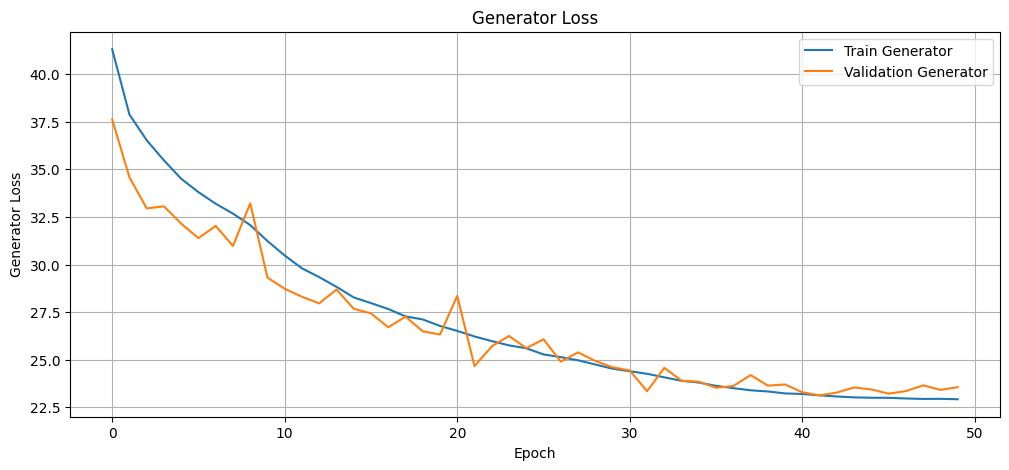

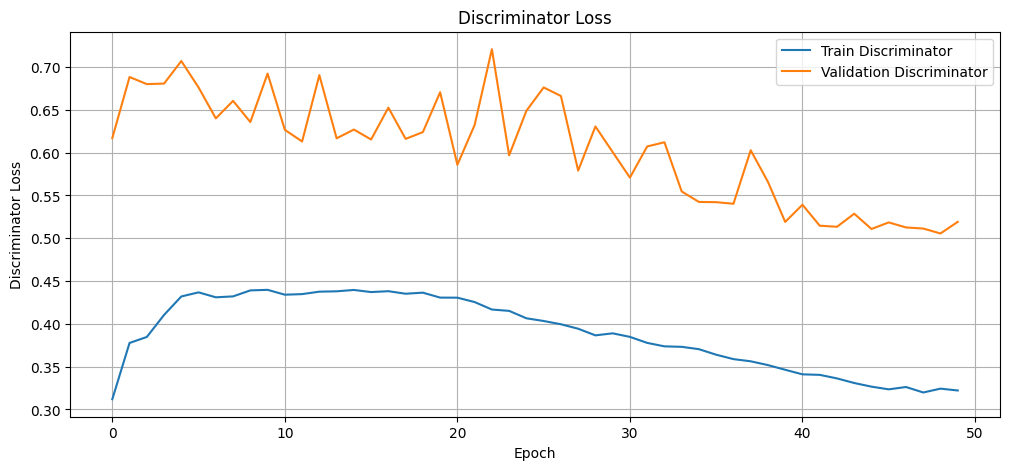

In [61]:
############################################################
# PART 13A : TRAINING FUNCTION
############################################################

from torch.amp import autocast

def train_one_epoch(
    generator,
    discriminator,
    loader,
    optimizer_G,
    optimizer_D,
    gan_loss,
    l1_loss,
    g_scaler,
    d_scaler,
    device,
    lambda_l1
):

    generator.train()
    discriminator.train()

    running_g_loss = 0.0
    running_d_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for sar, real_rgb in progress_bar:

        sar = sar.to(device, non_blocking=True)
        real_rgb = real_rgb.to(device, non_blocking=True)

        ####################################################
        # Train Discriminator
        ####################################################

        optimizer_D.zero_grad(set_to_none=True)

        with autocast(device_type=device.type):

            fake_rgb = generator(sar)

            pred_real = discriminator(
                sar,
                real_rgb
            )

            real_labels = torch.ones_like(pred_real)

            loss_real = gan_loss(
                pred_real,
                real_labels
            )

            pred_fake = discriminator(
                sar,
                fake_rgb.detach()
            )

            fake_labels = torch.zeros_like(pred_fake)

            loss_fake = gan_loss(
                pred_fake,
                fake_labels
            )

            d_loss = (
                loss_real +
                loss_fake
            ) / 2

        d_scaler.scale(d_loss).backward()

        d_scaler.step(optimizer_D)

        d_scaler.update()

        ####################################################
        # Train Generator
        ####################################################

        optimizer_G.zero_grad(set_to_none=True)

        with autocast(device_type=device.type):

            fake_rgb = generator(sar)

            pred_fake = discriminator(
                sar,
                fake_rgb
            )

            gan_component = gan_loss(
                pred_fake,
                torch.ones_like(pred_fake)
            )

            l1_component = l1_loss(
                fake_rgb,
                real_rgb
            )

            g_loss = (
                gan_component +
                lambda_l1 * l1_component
            )

        g_scaler.scale(g_loss).backward()

        g_scaler.step(optimizer_G)

        g_scaler.update()

        ####################################################
        # Statistics
        ####################################################

        running_g_loss += g_loss.item()

        running_d_loss += d_loss.item()

        progress_bar.set_postfix(

            G_Loss=f"{g_loss.item():.4f}",

            D_Loss=f"{d_loss.item():.4f}"

        )

    avg_g_loss = running_g_loss / len(loader)

    avg_d_loss = running_d_loss / len(loader)

    return avg_g_loss, avg_d_loss

############################################################
# PART 13B : VALIDATION FUNCTION
############################################################

def validate(
    generator,
    discriminator,
    loader,
    gan_loss,
    l1_loss,
    device,
    lambda_l1
):

    generator.eval()
    discriminator.eval()

    total_g_loss = 0.0
    total_d_loss = 0.0

    with torch.no_grad():

        for sar, real_rgb in loader:

            sar = sar.to(device)
            real_rgb = real_rgb.to(device)

            fake_rgb = generator(sar)

            pred_real = discriminator(sar, real_rgb)
            pred_fake = discriminator(sar, fake_rgb)

            d_real_loss = gan_loss(
                pred_real,
                torch.ones_like(pred_real)
            )

            d_fake_loss = gan_loss(
                pred_fake,
                torch.zeros_like(pred_fake)
            )

            d_loss = (d_real_loss + d_fake_loss) / 2

            g_gan_loss = gan_loss(
                pred_fake,
                torch.ones_like(pred_fake)
            )

            g_l1_loss = l1_loss(
                fake_rgb,
                real_rgb
            )

            g_loss = g_gan_loss + lambda_l1 * g_l1_loss

            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()

    avg_g = total_g_loss / len(loader)
    avg_d = total_d_loss / len(loader)

    return avg_g, avg_d

############################################################
# PART 13C : MAIN TRAINING LOOP
############################################################

history = {

    "train_g": [],
    "train_d": [],
    "val_g": [],
    "val_d": []

}

best_val_loss = float("inf")

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    print("=" * 70)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print("=" * 70)

    train_g_loss, train_d_loss = train_one_epoch(

        generator,
        discriminator,
        train_loader,
        optimizer_G,
        optimizer_D,
        gan_loss,
        l1_loss,
        g_scaler,
        d_scaler,
        DEVICE,
        LAMBDA_L1

    )

    val_g_loss, val_d_loss = validate(

        generator,
        discriminator,
        val_loader,
        gan_loss,
        l1_loss,
        DEVICE,
        LAMBDA_L1

    )

    scheduler_G.step()
    scheduler_D.step()

    history["train_g"].append(train_g_loss)
    history["train_d"].append(train_d_loss)
    history["val_g"].append(val_g_loss)
    history["val_d"].append(val_d_loss)

    print(f"Train G Loss : {train_g_loss:.4f}")
    print(f"Train D Loss : {train_d_loss:.4f}")
    print(f"Val   G Loss : {val_g_loss:.4f}")
    print(f"Val   D Loss : {val_d_loss:.4f}")

    ####################################################
    # Save Best Model
    ####################################################

    if val_g_loss < best_val_loss:

        best_val_loss = val_g_loss

        torch.save(
            generator.state_dict(),
            os.path.join(
                CHECKPOINT_DIR,
                "best_generator.pth"
            )
        )

        torch.save(
            discriminator.state_dict(),
            os.path.join(
                CHECKPOINT_DIR,
                "best_discriminator.pth"
            )
        )

        print("Best model saved.")

    ####################################################
    # Save Last Checkpoint
    ####################################################

    checkpoint = {

        "epoch": epoch,

        "generator": generator.state_dict(),

        "discriminator": discriminator.state_dict(),

        "optimizer_G": optimizer_G.state_dict(),

        "optimizer_D": optimizer_D.state_dict()

    }

    torch.save(

        checkpoint,

        os.path.join(
            CHECKPOINT_DIR,
            "checkpoint.pth"
        )

    )

print()

print("=" * 70)
print("Training Completed")
print("=" * 70)

total_time = (time.time() - start_time) / 60

print(f"Total Training Time : {total_time:.2f} Minutes")

############################################################
# PART 13D : PLOT LOSSES
############################################################

plt.figure(figsize=(12,5))

plt.plot(

    history["train_g"],

    label="Train Generator"

)

plt.plot(

    history["val_g"],

    label="Validation Generator"

)

plt.xlabel("Epoch")

plt.ylabel("Generator Loss")

plt.title("Generator Loss")

plt.legend()

plt.grid(True)

plt.show()



plt.figure(figsize=(12,5))

plt.plot(

    history["train_d"],

    label="Train Discriminator"

)

plt.plot(

    history["val_d"],

    label="Validation Discriminator"

)

plt.xlabel("Epoch")

plt.ylabel("Discriminator Loss")

plt.title("Discriminator Loss")

plt.legend()

plt.grid(True)

plt.show()

